In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("data/employee_attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [11]:
df.shape

(1470, 35)

In [12]:
TARGET = "Attrition"

FEATURES = [
    "Age",
    "BusinessTravel",
    "Department",
    "DistanceFromHome",
    "Education",
    "EducationField",
    "EnvironmentSatisfaction",
    "Gender",
    "JobInvolvement",
    "JobLevel",
    "JobRole",
    "JobSatisfaction",
    "MaritalStatus",
    "MonthlyIncome",
    "NumCompaniesWorked",
    "OverTime",
    "PercentSalaryHike",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "WorkLifeBalance",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

X = df[FEATURES]
y = df[TARGET]

print("Number of Features:", len(FEATURES))

Number of Features: 27


In [13]:
CATEGORICAL_FEATURES = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]

NUMERIC_FEATURES = [
    feature for feature in FEATURES
    if feature not in CATEGORICAL_FEATURES
]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 27)
Testing Data: (294, 27)


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES
        )
    ]
)

In [16]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

In [17]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest_model)
    ]
)

In [18]:
pipeline.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [19]:
y_pred = pipeline.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="Yes",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="Yes",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Yes",
    zero_division=0
)

print("Random Forest Performance")
print("-" * 35)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Random Forest Performance
-----------------------------------
Accuracy : 0.8503
Precision: 0.6667
Recall   : 0.1277
F1 Score : 0.2143


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.86      0.99      0.92       247
         Yes       0.67      0.13      0.21        47

    accuracy                           0.85       294
   macro avg       0.76      0.56      0.57       294
weighted avg       0.83      0.85      0.80       294



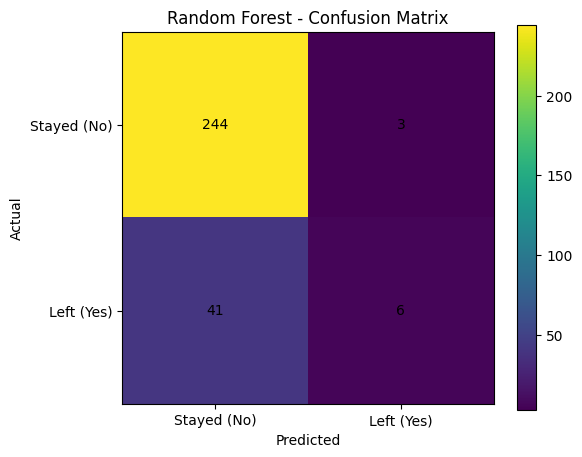

In [22]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.colorbar()

plt.xticks([0, 1], ["Stayed (No)", "Left (Yes)"])
plt.yticks([0, 1], ["Stayed (No)", "Left (Yes)"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest - Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()